# T QML Power Spectrum Analysis

This notebook provides a step-by-step analysis of QML power spectrum estimation for T (Temperature) data.

## 1. Import Required Libraries

In [65]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from mpi4py import MPI

# Import cosmocore modules
from cosmocore import (
    InputParams,
    do_derivative_step,
    matrix_mult,
    matrix_trace,
)

# Import quelo modules
from quelo import Spectra


# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("All imports successful!")
print(f"MPI size: {MPI.COMM_WORLD.Get_size()}, rank: {MPI.COMM_WORLD.Get_rank()}")

All imports successful!
MPI size: 1, rank: 0


In [66]:
def configure_plt():
    plt.rc("axes", labelsize=20, linewidth=1.5)
    plt.rc("xtick", direction="in", labelsize=15, top=True)
    plt.rc("ytick", direction="in", labelsize=15, right=True)

    plt.rc("xtick.major", width=1.1, size=5)
    plt.rc("ytick.major", width=1.1, size=5)

    plt.rc("xtick.minor", width=1.1, size=3)
    plt.rc("ytick.minor", width=1.1, size=3)

    plt.rc("lines", linewidth=2)
    plt.rc("legend", frameon=False, fontsize=15)
    plt.rc("figure", dpi=100, autolayout=True, figsize=[10, 7])
    plt.rc("savefig", dpi=300, bbox="tight")


configure_plt()

## 2. Setup Test Parameters and Configuration

In [67]:
# Set up test configuration paths
local_path = os.path.abspath(os.getcwd())
fields = "T"  # Use TQU configuration for debugging
nside = 4
param_file = f"{local_path}/../tests/data/nside{nside}/{fields}/config.yaml"

print(f"Local path: {local_path}")
print(f"Parameter file: {param_file}")
print(f"Parameter file exists: {os.path.exists(param_file)}")

# Load parameters
params = InputParams.read_parameter_file(param_file)

# Display key parameters
print("\n=== Key Parameters ===")
print(f"nside: {params.nside}")
print(f"spins: {params.spins}")
print(f"labels: {getattr(params, 'labels', 'Not specified')}")
print(f"nspectra: {params.nspectra}")
print(f"lmax: {params.lmax}")
print(f"nsims: {params.nsims}")
print(f"do_cross: {params.do_cross}")
print(f"calibration: {params.calibration}")

Local path: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/notebooks
Parameter file: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/notebooks/../tests/data/nside4/T/config.yaml
Parameter file exists: True

=== Key Parameters ===
nside: 4
spins: [0]
labels: ['T']
nspectra: 1
lmax: 16
nsims: 300
do_cross: False
calibration: 1.0


## 3. Initialize Spectra Instance

In [68]:
# Initialize Spectra instance
print("Creating Spectra instance...")
spectra = Spectra(param_file)

# Display MPI and basic info
print(f"MPI rank: {spectra.rank}")
print(f"MPI size: {spectra.size}")
print(f"Parameters loaded: {spectra.params is not None}")
print(f"Fisher instance created: {spectra.fisher_instance is not None}")

# Display initial variable states
print("\n=== Initial Variable States ===")
print(f"maps1: {spectra.maps1}")
print(f"maps2: {spectra.maps2}")
print(f"y: {spectra.y}")
print(f"ynb: {spectra.ynb}")
print(f"invfisher: {spectra.invfisher}")

Creating Spectra instance...
Starting Fisher matrix computation...
Starting Fisher matrix analysis pipeline
--------------------------------------------------------------------------------
Fisher matrix computation completed
Fisher matrix computation completed in 0.43 seconds
MPI rank: 0
MPI size: 1
Parameters loaded: True
Fisher instance created: True

=== Initial Variable States ===
maps1: None
maps2: None
y: None
ynb: None
invfisher: None


## 4. Setup Fields and Geometry

In [69]:
# Execute setup_fields() and setup_geometry()
print("=== Setting up fields ===")
spectra.setup_fields()
print("Fields setup completed")

print("\n=== Setting up geometry ===")
spectra.setup_geometry()
print("Geometry setup completed")

# Inspect results
print("\n=== Geometry Results ===")
print(f"npixs type: {type(spectra.npixs)}")
print(f"npixs: {spectra.npixs}")
print(f"n_active: {spectra.collection.n_active}")
print(f"Total pixels: {sum(spectra.collection.n_active)}")

if hasattr(spectra, "pixact") and spectra.pixact is not None:
    print(f"pixact type: {type(spectra.pixact)}")
    print(f"pixact length: {len(spectra.pixact)}")
    for i, pix in enumerate(spectra.pixact):
        print(
            f"  Field {i}: {len(pix) if hasattr(pix, '__len__') else pix} active pixels"
        )

# Check collection and spectra labels
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"\nSpectra labels: {spectra.collection.spectra_labels}")
    print(f"Number of spectra: {len(spectra.collection.spectra_labels)}")

    # This is the KEY issue we're investigating
    print("Expected spectra: ['TT']")
    print(f"Actual spectra: {spectra.collection.spectra_labels}")
else:
    print("Collection not available")

=== Setting up fields ===
Fields setup completed

=== Setting up geometry ===
Geometry setup completed

=== Geometry Results ===
npixs type: <class 'list'>
npixs: [192]
n_active: [192]
Total pixels: 192
pixact type: <class 'numpy.ndarray'>
pixact length: 1
  Field 0: 192 active pixels

Spectra labels: ['TT']
Number of spectra: 1
Expected spectra: ['TT']
Actual spectra: ['TT']


## 5. Load Maps Data

In [70]:
# Execute setup_maps() - this follows the exact pattern from spectra.run()
print("=== Loading maps ===")
# Read maps using the core functionality
ntot = sum(spectra.collection.n_active)
print(f"Total active pixels (ntot): {ntot}")
spectra.maps1 = np.empty((ntot, spectra.params.nsims), dtype=np.float64)

# Load from multi-extension FITS file
filename = f"{spectra.params.inputmapfile1.rsplit('_', 1)[0]}/maps/all_sims_TQU.fits"
filename = (
    f"{spectra.params.inputmapfile1.rsplit('sim', 1)[0]}"
    f"all_sims{spectra.params.endname1}.fits"
)
print(f"Loading from multi-extension FITS: {filename}")

# src/cosmoforge.quelo/tests/data/nside4/maps

with fits.open(filename) as hdul:
    print(f"Number of extensions: {len(hdul)}")
    for isim in range(spectra.params.nsims):
        ext_name = f"SIM_{isim:03d}"
        if ext_name in hdul:
            sim_data = hdul[ext_name].data
            sim = sim_data[0]  # T component only
            spectra.maps1[:, isim] = sim
        else:
            print(f"Warning: Extension {ext_name} not found")

# Apply calibration
spectra.maps1 *= spectra.params.calibration
print("Maps loaded")

print("\n=== Maps1 Info ===")
print(f"maps1 shape: {spectra.maps1.shape}")
print(f"maps1 dtype: {spectra.maps1.dtype}")
print(f"maps1 min/max: {spectra.maps1.min():.3e} / {spectra.maps1.max():.3e}")
print(f"maps1 mean/std: {spectra.maps1.mean():.3e} / {spectra.maps1.std():.3e}")

=== Loading maps ===
Total active pixels (ntot): 192
Loading from multi-extension FITS: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/maps/all_sims_TQU.fits
Number of extensions: 301
Maps loaded

=== Maps1 Info ===
maps1 shape: (192, 300)
maps1 dtype: float64
maps1 min/max: -1.789e+02 / 1.638e+02
maps1 mean/std: -1.306e-02 / 4.044e+01


## 6. Load Covariance Matrices

In [71]:
# Load covariance matrices - from spectra.run()
print("=== Loading covariance matrices ===")

ntot = sum(spectra.collection.n_active)
print(f"Total matrix size: {ntot} x {ntot}")

# Load invCov1 (inverted covariance matrix)
print(f"Loading invCov1 from: {spectra.params.outinvcovmatfile1}")
spectra.invCov1 = np.fromfile(spectra.params.outinvcovmatfile1).reshape((ntot, ntot))

# Load NCov1 (noise covariance matrix)
print(f"Loading NCov1 from: {spectra.params.covmatfile1}")
spectra.NCov1 = np.fromfile(spectra.params.covmatfile1).reshape((ntot, ntot))

# Inspect covariance matrices
print("\n=== Covariance Matrix Info ===")
print(f"invCov1 shape: {spectra.invCov1.shape}")
print(f"invCov1 dtype: {spectra.invCov1.dtype}")

print(f"\nNCov1 shape: {spectra.NCov1.shape}")
print(f"NCov1 dtype: {spectra.NCov1.dtype}")

=== Loading covariance matrices ===
Total matrix size: 192 x 192
Loading invCov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/T/invCOV1.bin
Loading NCov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/T/NCVM1.bin

=== Covariance Matrix Info ===
invCov1 shape: (192, 192)
invCov1 dtype: float64

NCov1 shape: (192, 192)
NCov1 dtype: float64


## 7. Setup Cls and Beams

In [72]:
print("=== Setting up Cls ===")
spectra.setup_cls()
print("Cls setup completed")

print("\n=== Setting up beams ===")
spectra.setup_beams()
print("Beams setup completed")

# Inspect the spectra collection
print("\n=== Spectra Collection Info ===")
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"Collection type: {type(spectra.collection)}")

    # Get spectra manager info
    if hasattr(spectra.collection, "spectra_manager"):
        mgr = spectra.collection.spectra_manager
        print(f"Spectra labels: {mgr.labels}")
        print(f"Number of spectra: {mgr.n_spectra}")

        # Show reference Cls values
        print("\n=== Reference Cls Values (first few ell) ===")
        if hasattr(mgr, "_cls_dict"):
            for label in mgr.labels:
                if label in mgr._cls_dict:
                    cls_vals = mgr._cls_dict[label]
                    print(f"{label}: {cls_vals[:5]} (ell=2-6)")

    # Get beam manager info
    if hasattr(spectra.collection, "beam_manager"):
        print(f"\nBeam manager available: {spectra.collection.beam_manager is not None}")
else:
    print("Collection not available")

=== Setting up Cls ===
Cls setup completed

=== Setting up beams ===
Beams setup completed

=== Spectra Collection Info ===
Collection type: <class 'cosmocore.fields.FieldCollection'>
Spectra labels: ['TT']
Number of spectra: 1

=== Reference Cls Values (first few ell) ===
TT: [421.50678481 273.79756797 194.4478264  146.59922523 115.18705562] (ell=2-6)

Beam manager available: True


## 8. Compute Smoothing Factors and vecmul

In [73]:
print("=== Computing smoothing factors ===")

smoothing_factors = spectra.collection.spectra_manager.compute_smoothing_factors(
    spectra.collection.beam_manager
)

print(f"Smoothing factors computed for: {list(smoothing_factors.keys())}")

# Create vecmul array
nell = spectra.params.nspectra * (spectra.params.lmax - 1)
vecmul = np.zeros(nell, dtype=np.float64)

print(
    f"\nvecmul array size: {nell} "
    f"(nspectra={spectra.params.nspectra}, lmax-1={spectra.params.lmax - 1})"
)

# Fill vecmul array
idx = 0
for ispec, spectrum_label in enumerate(spectra.collection.spectra_manager.labels):
    print(f"\nProcessing spectrum {ispec}: {spectrum_label}")

    if spectrum_label in smoothing_factors:
        smooth_factor = smoothing_factors[spectrum_label]
        print(f"  Smoothing factors (first 5): {smooth_factor[:5]}")

        for ell_idx in range(spectra.params.lmax - 1):
            vecmul[idx] = smooth_factor[ell_idx]
            idx += 1

        print(f"  Added {spectra.params.lmax - 1} factors to vecmul")
    else:
        print(f"  ⚠️  No smoothing factors found for {spectrum_label}")

spectra.vecmul = vecmul

print("\n=== vecmul Summary ===")
print(f"vecmul shape: {spectra.vecmul.shape}")
print(f"vecmul min/max: {spectra.vecmul.min():.3e} / {spectra.vecmul.max():.3e}")
print(f"vecmul first 10 values: {spectra.vecmul[:10]}")

=== Computing smoothing factors ===
Smoothing factors computed for: ['TT']

vecmul array size: 15 (nspectra=1, lmax-1=15)

Processing spectrum 0: TT
  Smoothing factors (first 5): [1.02655673 0.50316117 0.29398847 0.18959571 0.13013891]
  Added 15 factors to vecmul

=== vecmul Summary ===
vecmul shape: (15,)
vecmul min/max: 9.365e-03 / 1.027e+00
vecmul first 10 values: [1.02655673 0.50316117 0.29398847 0.18959571 0.13013891 0.09317342
 0.0687207  0.05178853 0.03965106 0.03071566]


## 9. Load and Process Fisher Matrix

In [74]:
print("=== Loading Fisher matrix ===")

# Load Fisher matrix
print(f"Loading Fisher from: {spectra.params.outfilefisher}")
spectra.invfisher = np.loadtxt(spectra.params.outfilefisher)

print(f"Fisher shape: {spectra.invfisher.shape}")
print(f"Fisher diagonal (first 5): {np.diag(spectra.invfisher)[:5]}")

print("\n=== Applying vecmul normalization ===")
nell = len(spectra.vecmul)
print(f"Applying normalization to {nell} x {nell} matrix")

print("Before normalization:")
print(f"  Fisher[0,0]: {spectra.invfisher[0, 0]:.3e}")
print(f"  vecmul[0]: {spectra.vecmul[0]:.3e}")

# Apply normalization
spectra.invfisher = spectra.invfisher * np.outer(spectra.vecmul, spectra.vecmul)

# Invert the normalized Fisher matrix
print("\n=== Inverting Fisher matrix ===")
spectra.invfisher = np.linalg.inv(spectra.invfisher)

=== Loading Fisher matrix ===
Loading Fisher from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.quelo/tests/data/nside4/T/fisher.dat
Fisher shape: (15, 15)
Fisher diagonal (first 5): [2.2267504e-06 1.4475891e-05 6.0856825e-05 1.9516142e-04 5.1621712e-04]

=== Applying vecmul normalization ===
Applying normalization to 15 x 15 matrix
Before normalization:
  Fisher[0,0]: 2.227e-06
  vecmul[0]: 1.027e+00

=== Inverting Fisher matrix ===


## 10. Initialize QML Variables

In [75]:
print("=== Initializing QML variables ===")

nell = spectra.params.nspectra * (spectra.params.lmax - 1)

# Initialize y vectors for QML estimation
spectra.y = np.zeros((spectra.params.nsims, nell), dtype=np.float64)
print(f"Initialized y array: shape={spectra.y.shape}, dtype={spectra.y.dtype}")

spectra.ynb = np.zeros(nell, dtype=np.float64)
print(f"Initialized ynb array: shape={spectra.ynb.shape}, dtype={spectra.ynb.dtype}")

# Prepare for main computation loop
ntot = sum(spectra.collection.n_active)
print("\n=== Computation Setup ===")
print(f"Total matrix size: {ntot}")
print(f"Number of multipole bins: {nell}")
print(f"Number of simulations: {spectra.params.nsims}")
print(f"MPI size: {spectra.size}")

# Allocate working arrays
der_s = np.zeros((ntot, ntot), dtype=np.float64)
E = np.zeros((ntot, ntot), dtype=np.float64)
print(f"Allocated working matrices: {der_s.shape}, {E.shape}")

print("\n✅ All variables initialized and ready for computation")

=== Initializing QML variables ===
Initialized y array: shape=(300, 15), dtype=float64
Initialized ynb array: shape=(15,), dtype=float64

=== Computation Setup ===
Total matrix size: 192
Number of multipole bins: 15
Number of simulations: 300
MPI size: 1
Allocated working matrices: (192, 192), (192, 192)

✅ All variables initialized and ready for computation


## 11. Main QML Computation Loop

In [76]:
print("=== Starting main QML computation ===")

nell = spectra.params.nspectra * (spectra.params.lmax - 1)
ntot = sum(spectra.collection.n_active)

# Allocate derivative matrix
der_s = np.zeros((ntot, ntot), dtype=np.float64)
E = np.zeros((ntot, ntot), dtype=np.float64)

start_time = time.time()

print(f"Processing {nell} multipole bins...")

# Track computation for debugging
computation_info = []

for il in range(nell):
    print(f"\n--- Processing bin {il} ---")

    # Compute derivative of signal matrix for this multipole
    spectrum_idx = il // (spectra.params.lmax - 1)
    ell = (il % (spectra.params.lmax - 1)) + 2

    spec_label = spectra.collection.spectra_labels[spectrum_idx]

    print(f"  Spectrum {spectrum_idx}: {spec_label}, ell={ell}")

    # This is where the derivative computation happens
    do_derivative_step(
        der_s,
        spectrum_idx,
        spectra.npixs,
        spectra.params.spins,
        ell,
        spectra.collection,
    )

    # Compute E matrix
    E = 0.5 * matrix_mult(spectra.invCov1, matrix_mult(der_s, spectra.invCov1))

    # Compute noise bias
    tr_ne = matrix_trace(spectra.NCov1, E)
    spectra.ynb[il] = tr_ne

    # Compute signal for each simulation
    for field_idx in range(spectra.params.nsims):
        spectra.y[field_idx, il] = matrix_mult(
            spectra.maps1[:, field_idx].T, matrix_mult(E, spectra.maps1[:, field_idx])
        )

    # Subtract noise bias
    for field_idx in range(spectra.params.nsims):
        spectra.y[field_idx, il] = spectra.y[field_idx, il] - spectra.ynb[il]

    # Store info for analysis
    info = {
        "il": il,
        "spectrum": spec_label,
        "ell": ell,
        "noise_bias": spectra.ynb[il],
        "signal_sim0": spectra.y[0, il],
        "der_s_trace": np.trace(der_s),
        "E_trace": np.trace(E),
    }
    computation_info.append(info)

    print(f"  Noise bias: {spectra.ynb[il]:.3e}")
    print(f"  Signal (sim 0): {spectra.y[0, il]:.3e}")

elapsed = time.time() - start_time
print(f"\nComputation completed in {elapsed:.2f} seconds")

=== Starting main QML computation ===
Processing 15 multipole bins...

--- Processing bin 0 ---
  Spectrum 0: TT, ell=2
  Noise bias: 1.887e-09
  Signal (sim 0): 1.071e-03

--- Processing bin 1 ---
  Spectrum 0: TT, ell=3
  Noise bias: 1.228e-08
  Signal (sim 0): 5.808e-03

--- Processing bin 2 ---
  Spectrum 0: TT, ell=4
  Noise bias: 5.164e-08
  Signal (sim 0): 2.015e-02

--- Processing bin 3 ---
  Spectrum 0: TT, ell=5
  Noise bias: 1.659e-07
  Signal (sim 0): 3.444e-02

--- Processing bin 4 ---
  Spectrum 0: TT, ell=6
  Noise bias: 4.396e-07
  Signal (sim 0): 6.217e-02

--- Processing bin 5 ---
  Spectrum 0: TT, ell=7
  Noise bias: 1.032e-06
  Signal (sim 0): 1.195e-01

--- Processing bin 6 ---
  Spectrum 0: TT, ell=8
  Noise bias: 1.951e-06
  Signal (sim 0): 9.802e-02

--- Processing bin 7 ---
  Spectrum 0: TT, ell=9
  Noise bias: 3.734e-06
  Signal (sim 0): 3.037e-01

--- Processing bin 8 ---
  Spectrum 0: TT, ell=10
  Noise bias: 5.566e-06
  Signal (sim 0): 2.047e-01

--- Proces

## 12. Final Matrix Multiplication

In [77]:
print("=== Applying final Fisher matrix multiplication ===")

print("Before final multiplication:")
print(f"y[0] first 5 values: {spectra.y[0, :5]}")
print(f"vecmul first 5 values: {spectra.vecmul[:5]}")
print(f"invfisher[0,0]: {spectra.invfisher[0, 0]:.3e}")

# Method from get_power_spectra() - this might be correct
power_spectra = np.zeros_like(spectra.y)
for field_idx in range(spectra.params.nsims):
    # Element-wise multiplication first, then matrix multiplication
    redy_times_vecmul = spectra.y[field_idx, :] * spectra.vecmul
    power_spectra[field_idx, :] = np.matmul(redy_times_vecmul, spectra.invfisher)

print(f"First 5 values: {power_spectra[0, :5]}")

print("\n✅ Final multiplication completed")

=== Applying final Fisher matrix multiplication ===
Before final multiplication:
y[0] first 5 values: [0.00107106 0.00580822 0.02015054 0.03443551 0.06216876]
vecmul first 5 values: [1.02655673 0.50316117 0.29398847 0.18959571 0.13013891]
invfisher[0,0]: 4.262e+05
First 5 values: [ 468.35279735  797.02314572 1124.87744018  928.38090446  919.00729362]

✅ Final multiplication completed


## 13. Validate Results and Output

=== Validation and Visualization ===
=== Plotting Original Fiducial Spectra ===


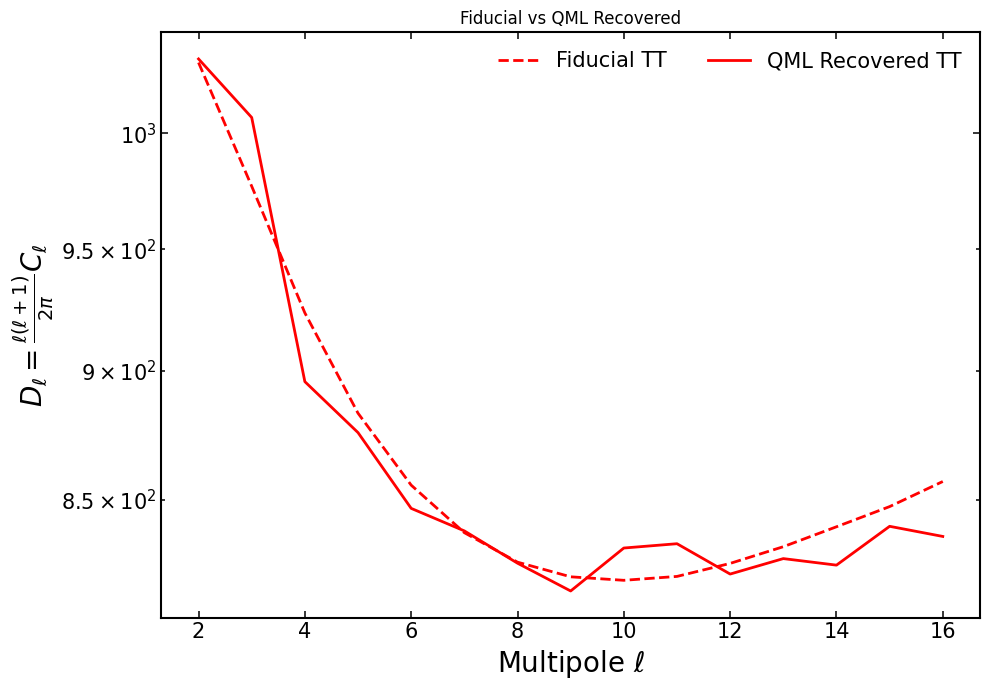

In [78]:
# Validate results and create diagnostic plots
print("=== Validation and Visualization ===")

# Create diagnostic plots
fig, ax = plt.subplots()

# Define colors and labels
colors = ["red", "dodgerblue", "forestgreen", "orange", "purple", "maroon"]
labels = ["TT", "EE", "BB", "TE", "TB", "EB"]

ell = np.arange(2, spectra.params.lmax + 1)
n_ell = len(ell)

# Plot original fiducial spectra (before normalizations and smoothing)
print("=== Plotting Original Fiducial Spectra ===")

# Load the original input spectra from the file used to generate simulations
original_clfid = np.loadtxt(params.inputclfile)
ell = original_clfid[:, 0].astype(int)

# Map original spectrum columns to labels
spectrum_map = {
    "TT": 1,  # Column 1 in original file
    "EE": 2,  # Column 2
    "BB": 3,  # Column 3
    "TE": 4,  # Column 4
    "TB": 5,  # Column 5 (should be zero)
    "EB": 6,  # Column 6 (should be zero)
}

# Plot original fiducial spectra
for ispec, spec_label in enumerate(["TT"]):
    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        # Extract the relevant ell range
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]
        ell_plot = ell[ell_mask]

        ax.plot(
            ell_plot,
            original_spectrum,
            "--",
            color=colors[ispec],
            linewidth=2,
            label=f"Fiducial {spec_label}",
            alpha=1,
        )

# Plot computed spectra for comparison
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell

    # Plot computed spectrum (average over simulations)
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
    ell_plot = ell[ell_mask]

    ax.plot(
        ell_plot,
        computed,
        color=colors[ispec],
        label=f"QML Recovered {spec_label}",
        alpha=1,
    )

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \frac{{\ell(\ell+1)}}{{2π}}C_\ell$")
ax.set_title("Fiducial vs QML Recovered")
ax.legend(ncol=2)
ax.set_yscale("log")
plt.show()

In [79]:
# Print comparison statistics
print("\n=== Spectrum Comparison Summary ===")
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]

        # Compare at overlapping ell values
        if spec_label in ["TB", "EB"]:
            print(f"{spec_label}: Original spectrum is zero!")
            mean = np.mean(computed)
            std = np.std(computed)

            print(f"{spec_label}: QML mean = {mean:.3f} ± {std:.3f}")
            continue

        ratio_mean = np.mean(computed / original_spectrum)
        ratio_std = np.std(computed / original_spectrum)

        print(f"{spec_label}: QML/Original ratio = {ratio_mean:.3f} ± {ratio_std:.3f}")


=== Spectrum Comparison Summary ===
TT: QML/Original ratio = 0.996 ± 0.015
